In [2]:
import numpy as np
#moyenne
lambda_ = 10.0

# Ongenereunevaleur aléatoire
valeur = np.random.poisson(lambda_)

# Puisuntableaude15valeurs aléatoires
valeurs = np.random.poisson(lambda_, size=15)
print(valeurs)


[12 11  9  8 14  8  7 11  9 10 10 11 13 12 13]


In [7]:


def poisson_knuth(lambda_, size=1):
    L = np.exp(-lambda_)
    resultats = np.zeros(size, dtype=int)
    
    for i in range(size):
        k = 0
        p = 1.0
        while True:
            k += 1
            p *= np.random.uniform(0, 1)
            if p <= L:
                break
        resultats[i] = k - 1
    
    return resultats

# Test
lambda_ = 10.0
echantillons = poisson_knuth(lambda_, size=15)
print(echantillons)

[ 9 12  9  7  4 13 10  9 11 12 16  7  8  7 10]


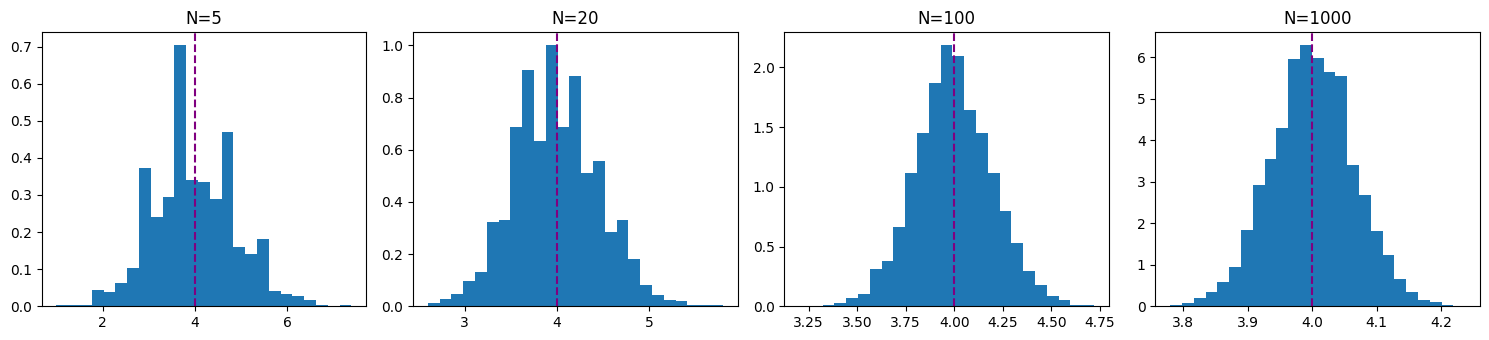

5 4.00788 0.8973438056843096 0.8944271909999159
20 4.001530000000001 0.44584432159667575 0.4472135954999579
100 4.0000919999999995 0.20002617712689508 0.2
1000 3.9985442000000004 0.06376011015015579 0.06324555320336758


In [3]:

import matplotlib.pyplot as plt

lam_star = 4.0
n_rep = 5000

Ns = [5, 20, 100, 1000]

fig, axs = plt.subplots(1, 4, figsize=(15, 3.5))

for i in range(4):
    N = Ns[i]
    lam_hat = []
    for j in range(n_rep):
        X = np.random.poisson(lam_star, N)
        lam_hat.append(np.mean(X))
    lam_hat = np.array(lam_hat)

    axs[i].hist(lam_hat, bins=25, density=True)
    axs[i].axvline(lam_star, color='purple', ls='--')
    axs[i].set_title(f"N={N}")

plt.tight_layout()
plt.show()

# moyenne et std pour verifier la convergence
for N in Ns:
    lam_hat = np.array([np.mean(np.random.poisson(lam_star, N)) for _ in range(n_rep)])
    print(N, np.mean(lam_hat), np.std(lam_hat), np.sqrt(lam_star/N))